In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
dataset=pd.read_csv('forest_cleaned.csv')

In [3]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [14]:
dataset['month'].value_counts()

month
8    62
7    61
6    60
9    60
Name: count, dtype: int64

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [5]:
dataset.isnull().any()

day            False
month          False
year           False
Temperature    False
RH             False
Ws             False
Rain           False
FFMC           False
DMC            False
DC             False
ISI            False
BUI            False
FWI            False
Classes        False
Region         False
dtype: bool

In [6]:
df=dataset.drop(['day','month','year'],axis=1)

In [9]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [8]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)

In [10]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [11]:
percentage=df['Classes'].value_counts(normalize=True)*100

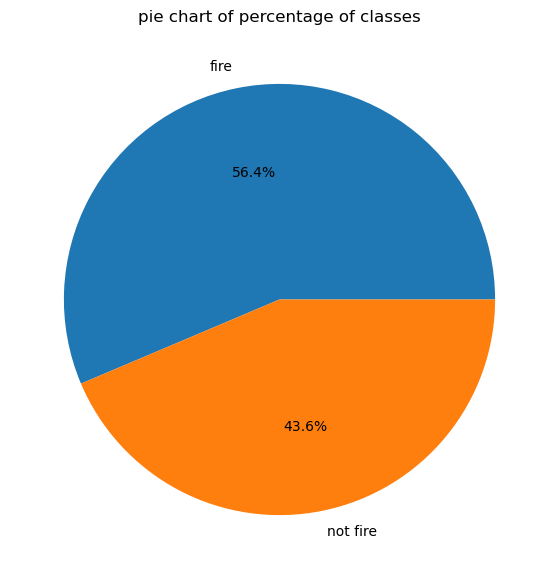

In [12]:
classlabels=['fire','not fire']
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title('pie chart of percentage of classes')
plt.show()

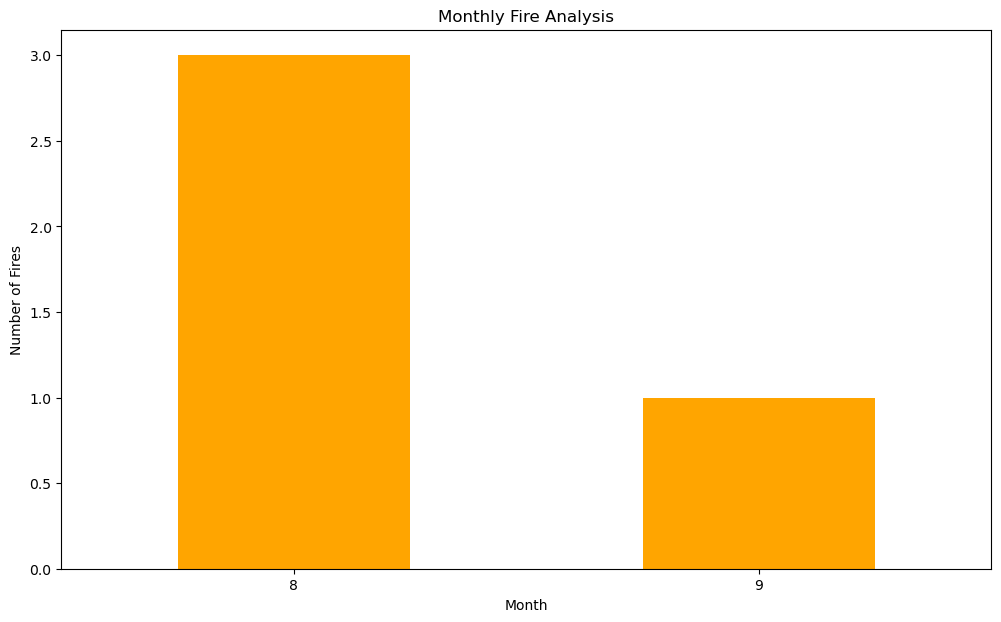

In [13]:
# Grouping by month and calculating fire occurrences
monthly_fire_analysis = dataset[dataset['Classes'] == 'fire'].groupby('month').size()

# Plotting the monthly fire analysis
plt.figure(figsize=(12, 7))
monthly_fire_analysis.plot(kind='bar', color='orange')
plt.title('Monthly Fire Analysis')
plt.xlabel('Month')
plt.ylabel('Number of Fires')
plt.xticks(rotation=0)
plt.show()

In [17]:
dataset['Classes']=np.where(dataset['Classes'].str.contains('not fire'),'not fire','fire')

Text(0.5, 1.0, 'Algeria region monthly fire analysis')

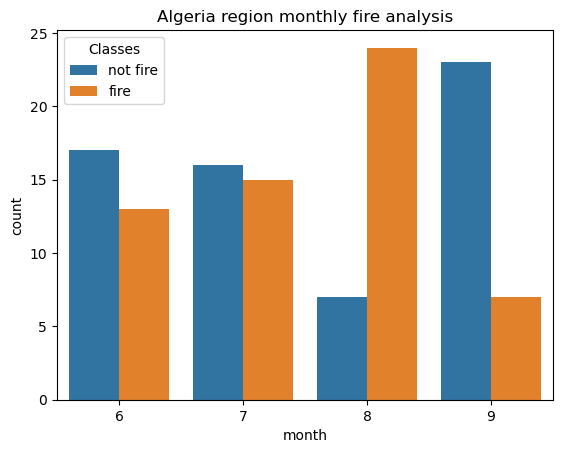

In [22]:
dftemp=dataset.loc[dataset['Region']==0]
sns.countplot(x='month', hue='Classes', data=dftemp)
plt.title('Algeria region monthly fire analysis')

Text(0.5, 1.0, 'Sidi Bel Abbes region monthly fire analysis')

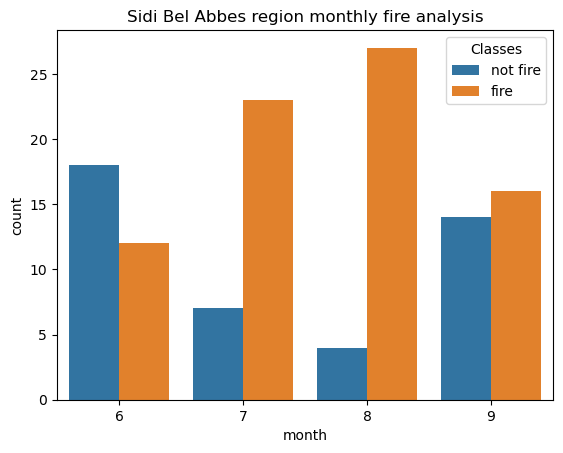

In [23]:
dftemp=dataset.loc[dataset['Region']==1]
sns.countplot(x='month', hue='Classes', data=dftemp)
plt.title('Sidi Bel Abbes region monthly fire analysis')

DIVIDING THE DATA

In [25]:
X=df.drop('FWI',axis=1)
y=df['FWI']

TRAIN TEST SPLIT

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [27]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((182, 11), (61, 11), (182,), (61,))

In [28]:
X.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.586639,0.089408
Classes,0.516015,-0.432161,-0.069964,-0.379097,0.769492,0.585658,0.511123,0.735197,0.586639,1.000000,0.162347


In [29]:
def correlation(dataset,threshold):
    col_corr=set() # Set of all the names of deleted columns
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i] # getting the name of column
                col_corr.add(colname)
    return col_corr

In [31]:
corr_features=correlation(X_train,0.85)
corr_features

{'BUI', 'DC'}

In [36]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
97,29,74,19,0.1,75.8,3.6,2.1,0,0
141,31,72,14,0.2,60.2,3.8,0.8,0,1
192,40,31,15,0.0,94.2,22.5,16.6,1,1
68,32,60,18,0.3,77.1,11.3,2.2,0,0
119,32,47,14,0.7,77.5,7.1,1.8,0,0
...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,0.2,0,0
14,28,80,17,3.1,49.4,3.0,0.4,0,0
92,25,76,17,7.2,46.0,1.3,0.2,0,0
179,34,59,16,0.0,88.1,19.5,7.4,1,1


In [ ]:
X_train=X_train.drop(corr_features,axis=1,inplace=True)
X_test=X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

In [37]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

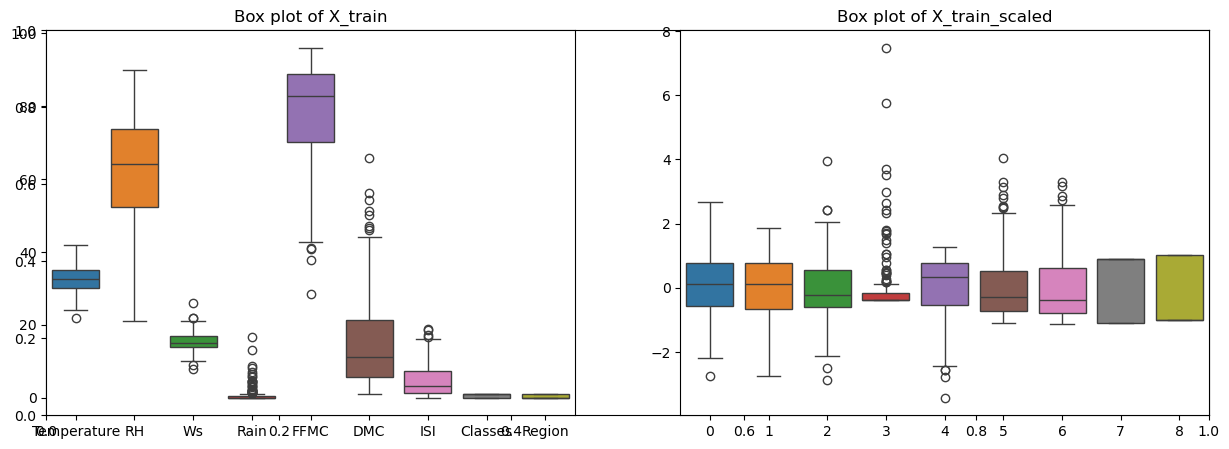

In [40]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('Box plot of X_train')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('Box plot of X_train_scaled')
plt.show()

LINEAR REGRESSION

Mean Squared Error: 0.6742766873791594
R^2 Score: 0.9847657384266951
adjusted R^2 Score: 0.9820773393255237


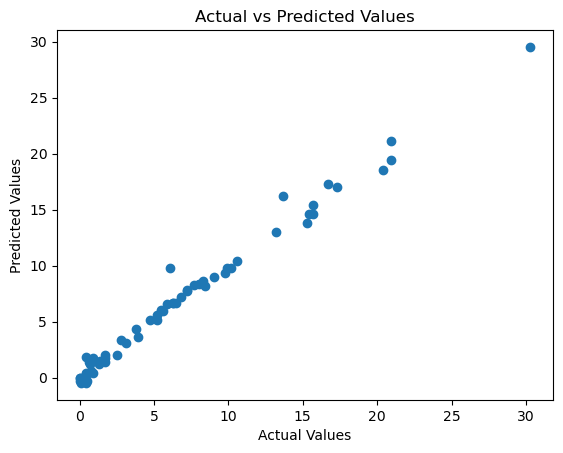

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R^2 Score:', r2_score(y_test, y_pred))
print('adjusted R^2 Score:', 1 - (1-r2_score(y_test, y_pred)) * (len(y_test)-1)/(len(y_test)-X_test_scaled.shape[1]-1))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

LASSO REGRESSION

Mean Absolute Error: 1.1331759949144085
R^2 Score: 0.9492020263112388
adjusted R^2 Score: 0.9402376780132222


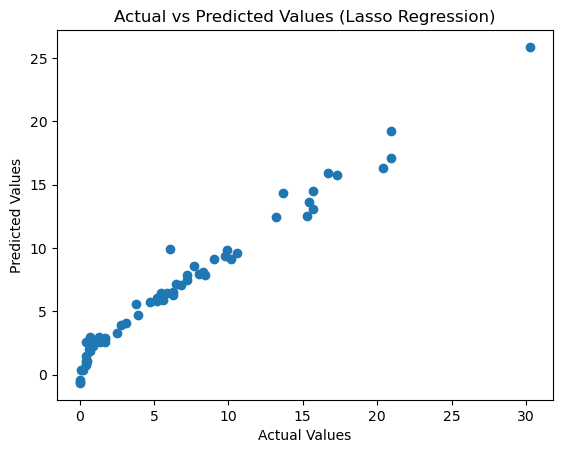

In [46]:
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred_lasso=lasso.predict(X_test_scaled)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_lasso))
print('R^2 Score:', r2_score(y_test, y_pred_lasso))
print('adjusted R^2 Score:', 1 - (1-r2_score(y_test, y_pred_lasso)) * (len(y_test)-1)/(len(y_test)-X_test_scaled.shape[1]-1))
plt.scatter(y_test, y_pred_lasso)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values') 
plt.title('Actual vs Predicted Values (Lasso Regression)')
plt.show()

LASSO CV

Best alpha: 0.05725391318234408
alpha values: [7.05853002 6.58280872 6.13914944 5.72539132 5.33951911 4.97965339
 4.64404142 4.33104857 4.03915039 3.76692517 3.51304702 3.27627941
 3.05546914 2.84954075 2.65749124 2.47838523 2.31135036 2.15557308
 2.01029467 1.87480753 1.74845178 1.63061198 1.52071419 1.41822315
 1.32263965 1.23349817 1.15036452 1.0728338  1.00052839 0.93309613
 0.87020857 0.81155943 0.75686304 0.705853   0.65828087 0.61391494
 0.57253913 0.53395191 0.49796534 0.46440414 0.43310486 0.40391504
 0.37669252 0.3513047  0.32762794 0.30554691 0.28495408 0.26574912
 0.24783852 0.23113504 0.21555731 0.20102947 0.18748075 0.17484518
 0.1630612  0.15207142 0.14182231 0.13226397 0.12334982 0.11503645
 0.10728338 0.10005284 0.09330961 0.08702086 0.08115594 0.0756863
 0.0705853  0.06582809 0.06139149 0.05725391 0.05339519 0.04979653
 0.04644041 0.04331049 0.0403915  0.03766925 0.03513047 0.03276279
 0.03055469 0.02849541 0.02657491 0.02478385 0.0231135  0.02155573
 0.02010295 0.018

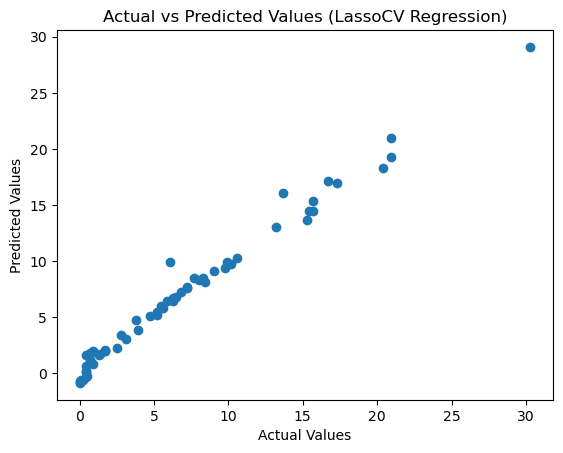

In [45]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error
lasso_cv=LassoCV(cv=5)
lasso_cv.fit(X_train_scaled,y_train)
print('Best alpha:', lasso_cv.alpha_)
print('alpha values:', lasso_cv.alphas_)
y_pred_lasso_cv=lasso_cv.predict(X_test_scaled)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_lasso_cv))
print('R^2 Score:', r2_score(y_test, y_pred_lasso_cv))
plt.scatter(y_test, y_pred_lasso_cv)
plt.xlabel('Actual Values') 
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (LassoCV Regression)')
plt.show()

RIDGE REGRESSION

Mean Absolute Error: 0.5642305340105721
R^2 Score: 0.9842993364555512


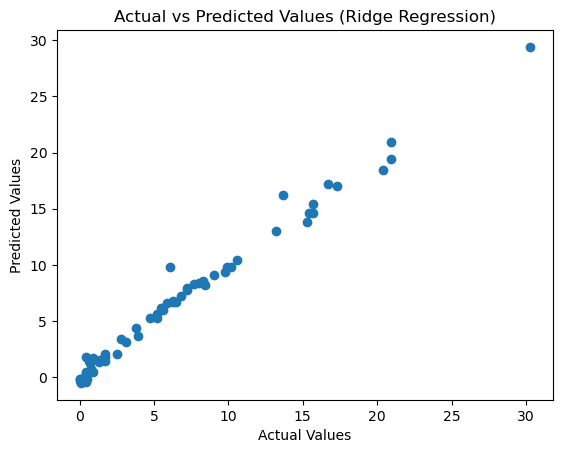

In [47]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred_ridge=ridge.predict(X_test_scaled)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_ridge))
print('R^2 Score:', r2_score(y_test, y_pred_ridge))
plt.scatter(y_test, y_pred_ridge)
plt.xlabel('Actual Values') 
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Ridge Regression)')
plt.show()

Best alpha: 1.0
Mean Absolute Error: 0.5642305340105721
R^2 Score: 0.9842993364555512


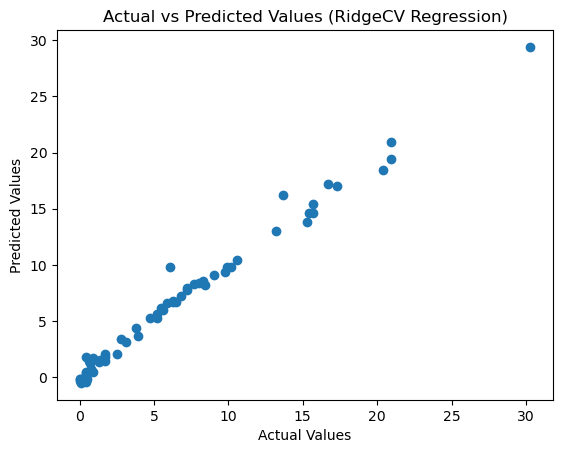

In [48]:
from sklearn.linear_model import RidgeCV
ridge_cv=RidgeCV(cv=5)
ridge_cv.fit(X_train_scaled,y_train)
y_pred_ridge_cv=ridge_cv.predict(X_test_scaled)
print('Best alpha:', ridge_cv.alpha_)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_ridge_cv))
print('R^2 Score:', r2_score(y_test, y_pred_ridge_cv))
plt.scatter(y_test, y_pred_ridge_cv)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (RidgeCV Regression)')
plt.show()


ELASTICNET REGRESSION

Mean Absolute Error: 1.8822353634896
R^2 Score: 0.8753460589519703


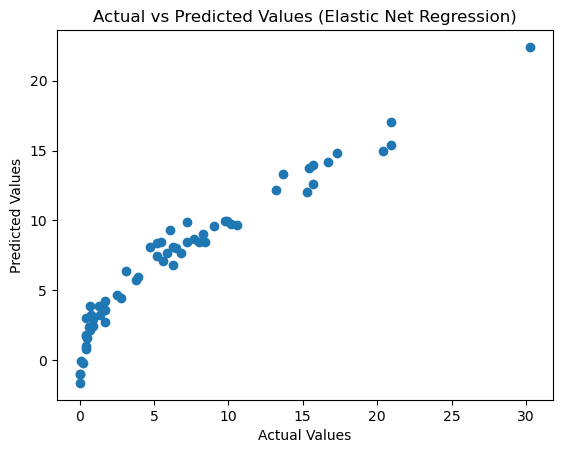

In [49]:
from sklearn.linear_model import ElasticNet
elastic_net=ElasticNet()
elastic_net.fit(X_train_scaled,y_train)
y_pred_elastic_net=elastic_net.predict(X_test_scaled)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_elastic_net))
print('R^2 Score:', r2_score(y_test, y_pred_elastic_net))
plt.scatter(y_test, y_pred_elastic_net)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Elastic Net Regression)')
plt.show()

ELASTIC CV

Best alpha: 0.04311146156383891
Best l1_ratio: 0.5
Mean Absolute Error: 0.6575946731430905
R^2 Score: 0.9814217587854941


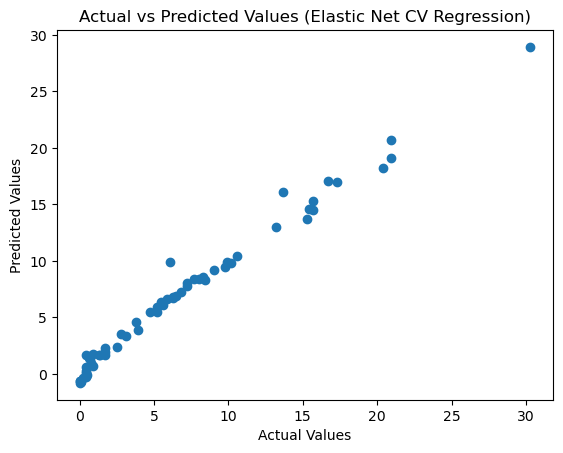

In [50]:
from sklearn.linear_model import ElasticNetCV
elastic_net_cv=ElasticNetCV(cv=5)
elastic_net_cv.fit(X_train_scaled,y_train)
print('Best alpha:', elastic_net_cv.alpha_)
print('Best l1_ratio:', elastic_net_cv.l1_ratio_)
y_pred_elastic_net_cv=elastic_net_cv.predict(X_test_scaled)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_elastic_net_cv))
print('R^2 Score:', r2_score(y_test, y_pred_elastic_net_cv))
plt.scatter(y_test, y_pred_elastic_net_cv)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Elastic Net CV Regression)')
plt.show()


PICKLING THE ML MODELS AND PREPROCESSING(STANDARD SCALAR)

In [51]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(ridge, open('ridge.pkl', 'wb'))